# Temporal Preprocessing, Windowing, and Features From Scratch

## 1. Why Time-Series Preprocessing Is Different

Time-series preprocessing must preserve **temporal causality**.

The central rule is:

> Information from the future must never be used to prepare a training example from the past.

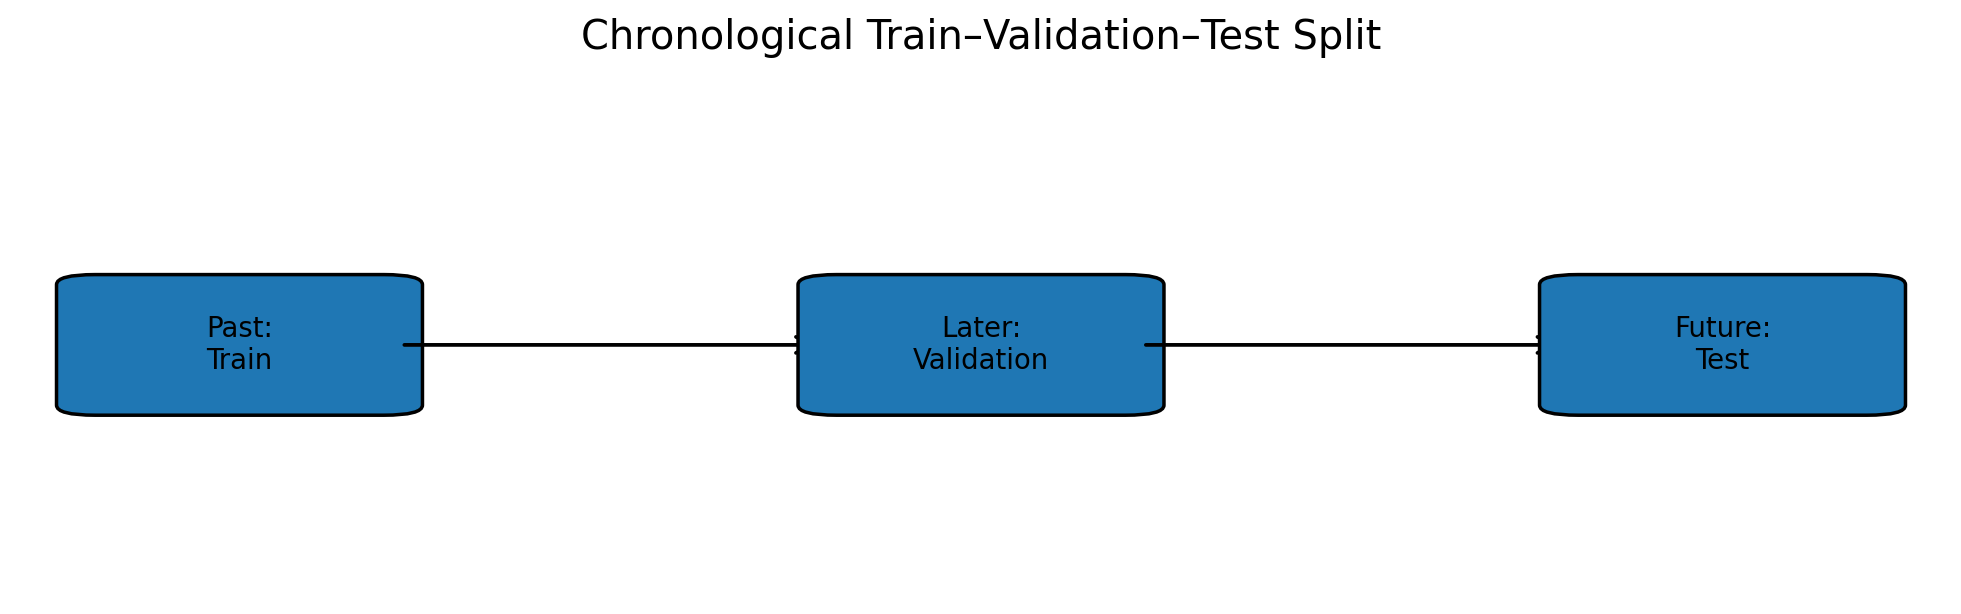

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain temporal leakage,
- create chronological train, validation, and test splits,
- fit scaling parameters on training data only,
- create safe lag and rolling features,
- use calendar and cyclical features,
- distinguish lookback, horizon, and stride,
- build single-step windows manually,
- build multi-step windows,
- construct multivariate temporal inputs,
- understand future-covariate availability,
- inspect model-ready array shapes.

## 3. Load and Clean the Dataset

In [3]:
"""import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(data_path)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

data["demand"] = data["demand"].interpolate(method="time")

print("Dataset shape:")
print(data.shape)

print()

print(data.head())"""

'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ndata_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(data_path)\n\ndata["timestamp"] = pd.to_datetime(data["timestamp"])\n\ndata = data.set_index("timestamp")\n\ndata["demand"] = data["demand"].interpolate(method="time")\n\nprint("Dataset shape:")\nprint(data.shape)\n\nprint()\n\nprint(data.head())'

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

data["demand"] = data["demand"].interpolate(method="time")

print("Dataset shape:")
print(data.shape)

print()

print(data.head())

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand.csv
Dataset shape:
(2880, 3)

                        demand  temperature   humidity
timestamp                                             
2024-01-01 00:00:00  54.247024    15.695400  62.063680
2024-01-01 01:00:00  57.721087    15.044949  61.358504
2024-01-01 02:00:00  56.020419    16.844586  63.553905
2024-01-01 03:00:00  56.303220    19.182494  64.144216
2024-01-01 04:00:00  60.937876    18.172185  53.719428


## 4. Temporal Data Leakage

Leakage happens when information unavailable at forecast time influences training.

Examples:

```text
Future target used as a feature                 ❌
Scaler fitted on train + validation + test      ❌
Random split before forecasting                 ❌
Centered rolling average using future points    ❌
```

## 5. Why Random Splitting Is Wrong

For forecasting, training should represent the past and testing should represent the future.

Correct conceptual order:

```text
Past → Train → Validation → Test → Future
```

## 6. Chronological Split

In [5]:
number_of_rows = len(data)

train_end = int(number_of_rows * 0.70)

validation_end = int(number_of_rows * 0.85)

train_data = data.iloc[:train_end].copy()

validation_data = data.iloc[train_end:validation_end].copy()

test_data = data.iloc[validation_end:].copy()

print("Training rows:")
print(len(train_data))

print()

print("Validation rows:")
print(len(validation_data))

print()

print("Test rows:")
print(len(test_data))

Training rows:
2015

Validation rows:
433

Test rows:
432


In [6]:
print("Training period:")
print(train_data.index.min())
print(train_data.index.max())

print()

print("Validation period:")
print(validation_data.index.min())
print(validation_data.index.max())

print()

print("Test period:")
print(test_data.index.min())
print(test_data.index.max())

Training period:
2024-01-01 00:00:00
2024-03-24 22:00:00

Validation period:
2024-03-24 23:00:00
2024-04-11 23:00:00

Test period:
2024-04-12 00:00:00
2024-04-29 23:00:00


## 7. Visualize the Split

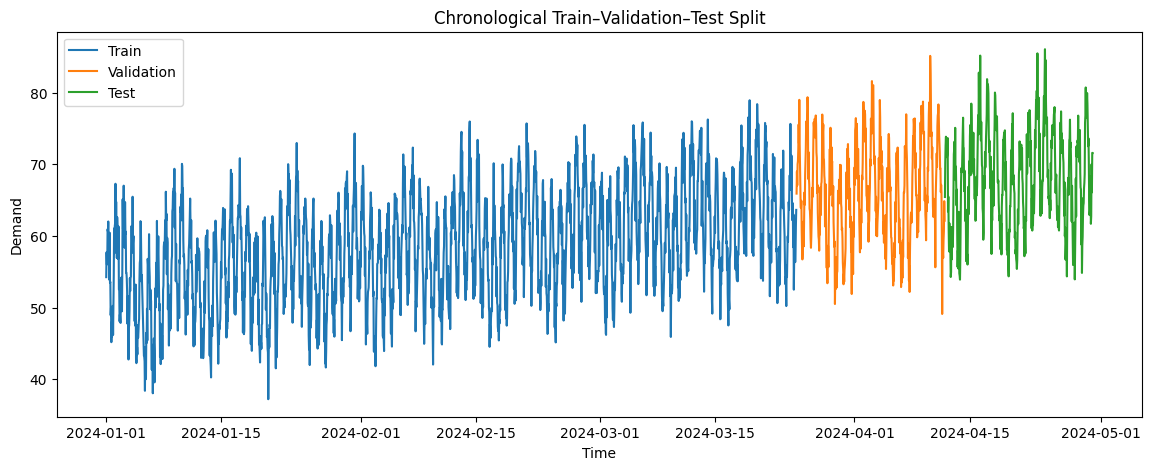

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(train_data.index, train_data["demand"], label="Train")

plt.plot(validation_data.index, validation_data["demand"], label="Validation")

plt.plot(test_data.index, test_data["demand"], label="Test")

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Chronological Train–Validation–Test Split")
plt.legend()

plt.show()

## 8. Scaling Without Leakage

Standardization uses:

\[
z = rac{x-\mu}{\sigma}
\]

The mean and standard deviation must be computed from **training data only**.

In [8]:
train_mean = train_data["demand"].mean()

train_std = train_data["demand"].std()

print("Training mean:")
print(train_mean)

print()

print("Training standard deviation:")
print(train_std)

Training mean:
58.36969108457328

Training standard deviation:
7.6449112217826425


In [9]:
train_scaled = (train_data["demand"] - train_mean) / train_std

validation_scaled = (validation_data["demand"] - train_mean) / train_std

test_scaled = (test_data["demand"] - train_mean) / train_std

print("Scaled training mean:")
print(train_scaled.mean())

print()

print("Scaled training standard deviation:")
print(train_scaled.std())

Scaled training mean:
-9.027242697498047e-16

Scaled training standard deviation:
0.9999999999999999


Test values can legitimately fall outside the training-scale range. That may reflect future distribution shift rather than an error.

## 9. Inverse Transformation

A scaled forecast can be converted back using:

$$
x = z\sigma+\mu
$$

In [10]:
scaled_prediction = 1.25

original_prediction = scaled_prediction * train_std + train_mean

print("Scaled prediction:")
print(scaled_prediction)

print()

print("Original-unit prediction:")
print(original_prediction)

Scaled prediction:
1.25

Original-unit prediction:
67.92583011180159


## 10. Create Lag Features

Valid forecasting features at time \(t\) can use earlier values such as:

```text
t - 1
t - 24
t - 168
```

In [11]:
feature_data = data[["demand", "temperature", "humidity"]].copy()

feature_data["demand_lag_1"] = feature_data["demand"].shift(1)

feature_data["demand_lag_24"] = feature_data["demand"].shift(24)

feature_data["demand_lag_168"] = feature_data["demand"].shift(168)

print(feature_data.head(170))

                        demand  temperature   humidity  demand_lag_1  \
timestamp                                                              
2024-01-01 00:00:00  54.247024    15.695400  62.063680           NaN   
2024-01-01 01:00:00  57.721087    15.044949  61.358504     54.247024   
2024-01-01 02:00:00  56.020419    16.844586  63.553905     57.721087   
2024-01-01 03:00:00  56.303220    19.182494  64.144216     56.020419   
2024-01-01 04:00:00  60.937876    18.172185  53.719428     56.303220   
...                        ...          ...        ...           ...   
2024-01-07 21:00:00  46.575344    17.628146  61.535401     42.809858   
2024-01-07 22:00:00  52.499246    17.088706  70.556943     46.575344   
2024-01-07 23:00:00  53.049652    17.894029  67.159363     52.499246   
2024-01-08 00:00:00  58.496312    14.656457  68.722983     53.049652   
2024-01-08 01:00:00  59.098495    14.183289  69.653371     58.496312   

                     demand_lag_24  demand_lag_168  
timestamp 

## 11. Safe Rolling Features

For predicting time \(t\), a rolling feature should use values available **before** \(t\).

A safe pattern is:

```python
series.shift(1).rolling(window).mean()
```

In [12]:
feature_data["rolling_mean_24"] = feature_data["demand"].shift(1).rolling(24).mean()

feature_data["rolling_std_24"] = feature_data["demand"].shift(1).rolling(24).std()

print(
    feature_data[
        ["demand", "rolling_mean_24", "rolling_std_24"]
    ].head(30)
)

                        demand  rolling_mean_24  rolling_std_24
timestamp                                                      
2024-01-01 00:00:00  54.247024              NaN             NaN
2024-01-01 01:00:00  57.721087              NaN             NaN
2024-01-01 02:00:00  56.020419              NaN             NaN
2024-01-01 03:00:00  56.303220              NaN             NaN
2024-01-01 04:00:00  60.937876              NaN             NaN
2024-01-01 05:00:00  60.640121              NaN             NaN
2024-01-01 06:00:00  62.018968              NaN             NaN
2024-01-01 07:00:00  60.222900              NaN             NaN
2024-01-01 08:00:00  59.914532              NaN             NaN
2024-01-01 09:00:00  53.885719              NaN             NaN
2024-01-01 10:00:00  60.446115              NaN             NaN
2024-01-01 11:00:00  53.464678              NaN             NaN
2024-01-01 12:00:00  53.590361              NaN             NaN
2024-01-01 13:00:00  48.926701          

## 12. Calendar Features

Temporal behavior may depend on:

- hour of day,
- day of week,
- weekend,
- month,
- holiday or operational schedule.

In [13]:
feature_data["hour"] = feature_data.index.hour

feature_data["day_of_week"] = feature_data.index.dayofweek

feature_data["is_weekend"] = (feature_data["day_of_week"] >= 5).astype(int)

print(
    feature_data[
        ["hour", "day_of_week", "is_weekend"]
    ].head()
)

                     hour  day_of_week  is_weekend
timestamp                                         
2024-01-01 00:00:00     0            0           0
2024-01-01 01:00:00     1            0           0
2024-01-01 02:00:00     2            0           0
2024-01-01 03:00:00     3            0           0
2024-01-01 04:00:00     4            0           0


## 13. Cyclical Encoding

Hour 23 and hour 0 are adjacent in time but numerically far apart.

Use:

$$
\sin\left(\frac{2\pi h}{24}\right)
$$

and:

$$
\cos\left(\frac{2\pi h}{24}\right)
$$

In [14]:
feature_data["hour_sin"] = np.sin(
    2.0 * np.pi * feature_data["hour"] / 24.0
)

feature_data["hour_cos"] = np.cos(
    2.0 * np.pi * feature_data["hour"] / 24.0
)

print(
    feature_data[
        ["hour", "hour_sin", "hour_cos"]
    ].head(25)
)

                     hour      hour_sin      hour_cos
timestamp                                            
2024-01-01 00:00:00     0  0.000000e+00  1.000000e+00
2024-01-01 01:00:00     1  2.588190e-01  9.659258e-01
2024-01-01 02:00:00     2  5.000000e-01  8.660254e-01
2024-01-01 03:00:00     3  7.071068e-01  7.071068e-01
2024-01-01 04:00:00     4  8.660254e-01  5.000000e-01
2024-01-01 05:00:00     5  9.659258e-01  2.588190e-01
2024-01-01 06:00:00     6  1.000000e+00  6.123234e-17
2024-01-01 07:00:00     7  9.659258e-01 -2.588190e-01
2024-01-01 08:00:00     8  8.660254e-01 -5.000000e-01
2024-01-01 09:00:00     9  7.071068e-01 -7.071068e-01
2024-01-01 10:00:00    10  5.000000e-01 -8.660254e-01
2024-01-01 11:00:00    11  2.588190e-01 -9.659258e-01
2024-01-01 12:00:00    12  1.224647e-16 -1.000000e+00
2024-01-01 13:00:00    13 -2.588190e-01 -9.659258e-01
2024-01-01 14:00:00    14 -5.000000e-01 -8.660254e-01
2024-01-01 15:00:00    15 -7.071068e-01 -7.071068e-01
2024-01-01 16:00:00    16 -8

## 14. Sliding Windows

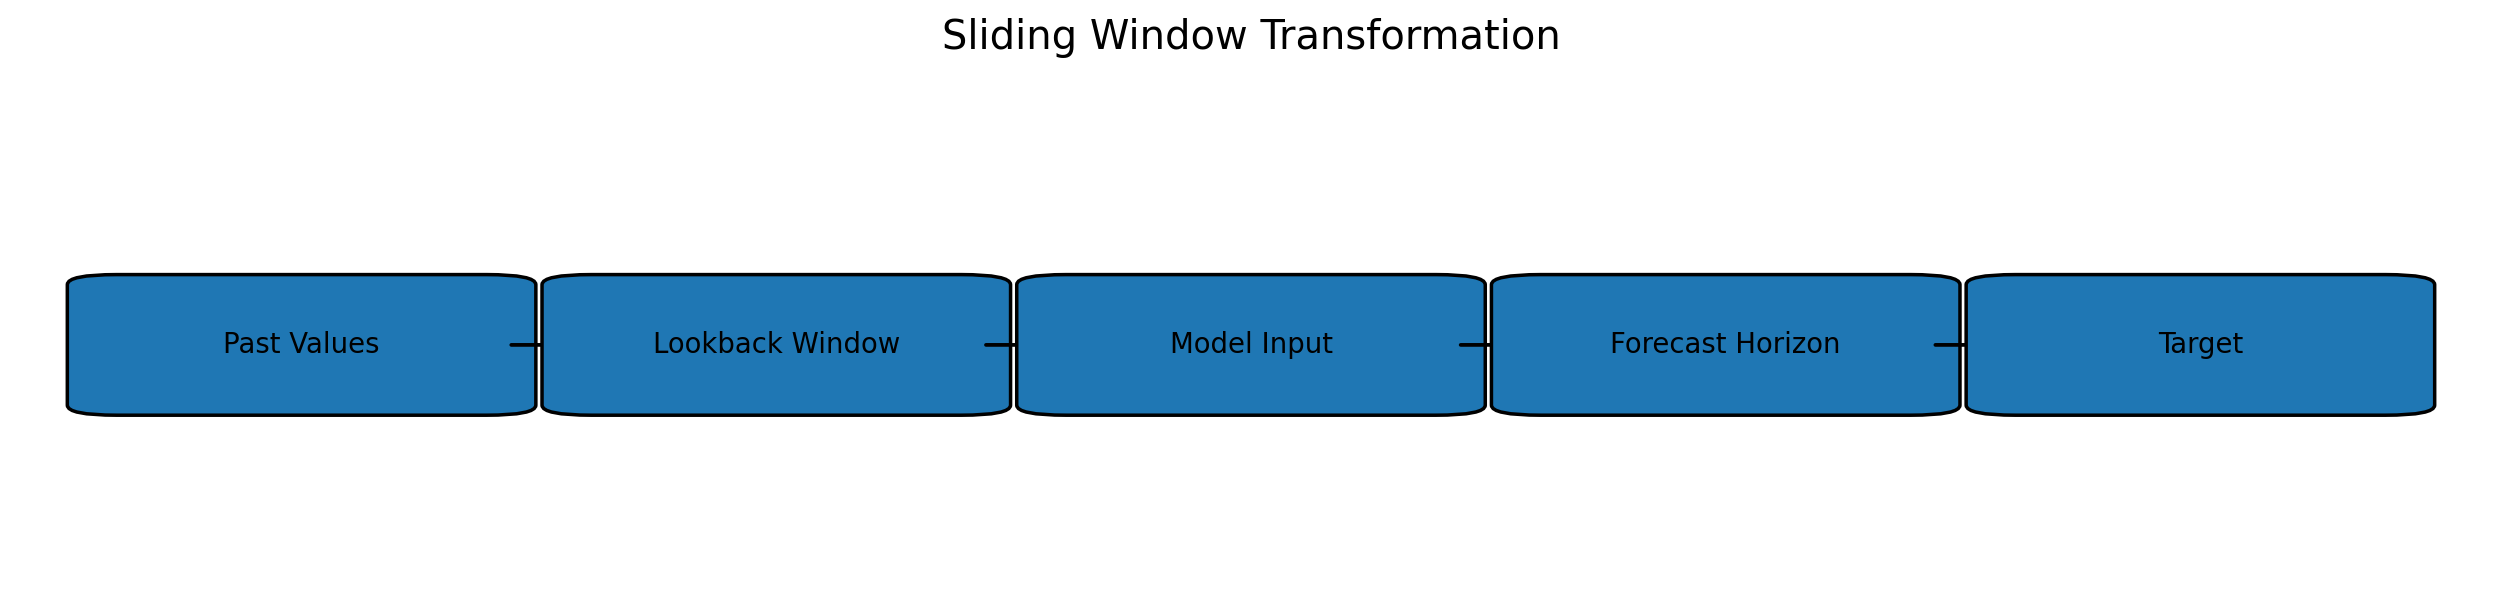

A forecasting model often receives a fixed past window and predicts one or more future values.

## 15. Lookback, Horizon, and Stride

### Lookback
Amount of historical context.

### Forecast horizon
How far into the future the model predicts.

### Stride
How far the window moves before the next sample is created.

## 16. Manual Single-Step Windowing

```text
Series:
10, 12, 14, 16, 18, 20

Lookback = 3

Input           Target
10 12 14   →      16
12 14 16   →      18
14 16 18   →      20
```

In [15]:
series = np.array([10, 12, 14, 16, 18, 20], dtype=float)

lookback = 3

input_windows = []

targets = []

for start_index in range(0, len(series) - lookback):
    end_index = start_index + lookback

    input_window = series[start_index:end_index]

    target = series[end_index]

    input_windows.append(input_window)

    targets.append(target)

print("Input windows:")
print(input_windows)

print()

print("Targets:")
print(targets)

Input windows:
[array([10., 12., 14.]), array([12., 14., 16.]), array([14., 16., 18.])]

Targets:
[np.float64(16.0), np.float64(18.0), np.float64(20.0)]


## 17. Convert to Arrays and Inspect Shapes

In [16]:
X = np.array(input_windows)

y = np.array(targets)

print("X shape:")
print(X.shape)

print()

print("y shape:")
print(y.shape)

X shape:
(3, 3)

y shape:
(3,)


A dense model may use:

```text
(samples, lookback)
```

A sequence model commonly uses:

```text
(samples, timesteps, features)
```

## 18. Reusable Single-Step Window Function

In [17]:
def create_single_step_windows(values, lookback):
    X = []
    y = []

    for start_index in range(0, len(values) - lookback):
        end_index = start_index + lookback

        input_window = values[start_index:end_index]

        target = values[end_index]

        X.append(input_window)

        y.append(target)

    X = np.array(X)

    y = np.array(y)

    return X, y

In [18]:
train_values = train_scaled.to_numpy()

X_train, y_train = create_single_step_windows(
    train_values,
    lookback=24
)

print("X_train shape:")
print(X_train.shape)

print()

print("y_train shape:")
print(y_train.shape)

X_train shape:
(1991, 24)

y_train shape:
(1991,)


## 19. Add the Feature Dimension

In [19]:
X_train_sequence = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("Sequence shape:")
print(X_train_sequence.shape)

Sequence shape:
(1991, 24, 1)


## 20. Multi-Step Forecasting

```text
Lookback = 4
Horizon = 3

[10, 12, 14, 16] → [18, 20, 22]
```

In [20]:
multi_series = np.array(
    [10, 12, 14, 16, 18, 20, 22, 24],
    dtype=float
)

lookback = 4

horizon = 3

inputs = []

targets = []

maximum_start = len(multi_series) - lookback - horizon + 1

for start_index in range(maximum_start):
    input_end = start_index + lookback

    target_end = input_end + horizon

    input_window = multi_series[start_index:input_end]

    target_window = multi_series[input_end:target_end]

    inputs.append(input_window)

    targets.append(target_window)

print("Inputs:")
print(inputs)

print()

print("Multi-step targets:")
print(targets)

Inputs:
[array([10., 12., 14., 16.]), array([12., 14., 16., 18.])]

Multi-step targets:
[array([18., 20., 22.]), array([20., 22., 24.])]


## 21. Recursive vs Direct Multi-Step Forecasting

### Recursive

```text
predict t+1
use that prediction
predict t+2
...
```

Problem: errors can accumulate.

### Direct multi-output

```text
Past → [t+1, t+2, ..., t+H]
```

All horizons are predicted together.

## 22. Multivariate Forecasting

A multivariate input can contain multiple variables at each timestep:

```text
demand
temperature
humidity
```

Expected shape:

```text
(samples, timesteps, features)
```

In [21]:
multivariate_values = train_data[
    ["demand", "temperature", "humidity"]
].to_numpy()

print("Raw multivariate shape:")
print(multivariate_values.shape)

Raw multivariate shape:
(2015, 3)


In [22]:
def create_multivariate_windows(values, target_column_index, lookback):
    X = []
    y = []

    for start_index in range(0, len(values) - lookback):
        end_index = start_index + lookback

        input_window = values[start_index:end_index, :]

        target = values[end_index, target_column_index]

        X.append(input_window)

        y.append(target)

    X = np.array(X)

    y = np.array(y)

    return X, y

In [23]:
X_multi, y_multi = create_multivariate_windows(
    multivariate_values,
    target_column_index=0,
    lookback=24
)

print("Multivariate X shape:")
print(X_multi.shape)

print()

print("Multivariate y shape:")
print(y_multi.shape)

Multivariate X shape:
(1991, 24, 3)

Multivariate y shape:
(1991,)


## 23. Future Covariate Availability

Suppose we forecast demand 24 hours ahead using temperature.

Two cases:

### Future temperature is genuinely known
For example, a weather forecast is available.

### Future actual temperature is taken directly from the test dataset
That is future information and can be leakage.

This distinction is crucial in multivariate forecasting.

## 24. Stride

Stride controls how far the window moves.

```text
stride = 1
```

creates highly overlapping samples.

Larger stride reduces overlap, number of samples, and computational cost.

## 25. Split-Boundary Context

The first validation target may legitimately use the last 24 training observations as historical context.

The important rule is:

> Historical input may cross the split boundary backward, but future target information must never cross into training.

This is why splitting the timeline first and then constructing target-aware windows is safer than windowing everything and randomly splitting later.

## 26. Final Model-Ready Shapes

A common deep-learning representation is:

```text
X:
(samples, lookback, features)

y single-step:
(samples,)

y multi-step:
(samples, horizon)
```

Always print these shapes before training.

## 27. Why This Notebook Matters

Many forecasting errors occur before model training:

```text
wrong split
leaky normalization
wrong target alignment
future covariate leakage
incorrect horizon
incorrect window offset
```

A sophisticated neural network cannot repair an invalid temporal pipeline.

## 28. Connection to the Next Notebook

We now know how to formulate valid temporal training examples.

The next notebook establishes:

```text
simple baselines
forecast metrics
residual analysis
rolling evaluation
uncertainty
```

These become the benchmark that later deep-learning models must beat.

## 29. Key Takeaways

- Forecasting data should be split chronologically.
- Preprocessing parameters must be learned from training data only.
- Lag and rolling features must use past information only.
- Lookback determines historical context.
- Horizon determines how far ahead we forecast.
- Windowing converts a temporal sequence into supervised-learning samples.
- Multivariate inputs add multiple features per timestep.
- Multi-step targets require careful target alignment.
- Future covariates are valid only if they are genuinely available at forecast time.